In [68]:
## Regressao Polinomial

In [69]:
from matplotlib import pyplot as plt
import pandas as pd
import pylab as pl
import numpy as np
from sklearn import linear_model
from sklearn.preprocessing import PolynomialFeatures


In [91]:
df=pd.read_csv('homeprices.csv')
df

,area,price
0,100,250000
1,120,300000
2,150,450000
3,200,600000
4,250,800000
5,300,1200000
6,500,4000000
7,1000,10000000


In [71]:
poly_features=PolynomialFeatures(degree=4)
areas_casas_poly=poly_features.fit_transform(df[['area']])

reg=linear_model.LinearRegression()
reg.fit(areas_casas_poly,df.price)

LinearRegression()

In [72]:
print(f"Intercepto (b0): {reg.intercept_}")
print(f"Coeficientes (b1, b2): {reg.coef_}")

Intercepto (b0): -371701.7904246487
Coeficientes (b1, b2): [ 0.00000000e+00  9.75030221e+03 -4.82785022e+01  1.36178062e-01
 -8.72781802e-05]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


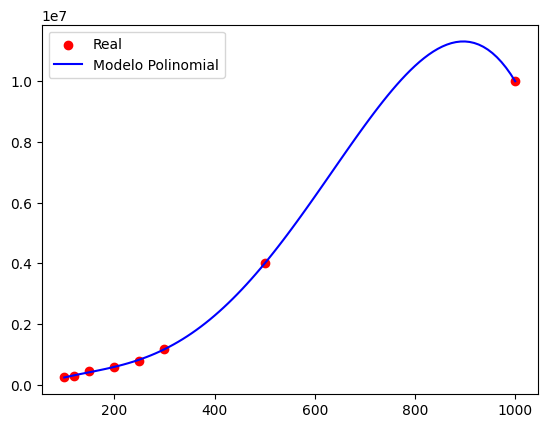

In [73]:
import matplotlib.pyplot as plt

# Criar uma sequência de valores de área para desenhar a curva
X_range = np.linspace(df.area.min(), df.area.max(), 100).reshape(-1, 1)
X_range_poly = poly_features.transform(X_range)
y_pred_curva = reg.predict(X_range_poly)

plt.scatter(df.area, df.price, color='red', label='Real')
plt.plot(X_range, y_pred_curva, color='blue', label='Modelo Polinomial')
plt.legend()
plt.show()

In [74]:
#Predições

area_especifica=np.array([[750]])
area_especifica_casa=poly_features.fit_transform(area_especifica)

reg.predict(area_especifica_casa)

array([9619125.74727095])

In [75]:
area_df=pd.read_csv('areas.csv')
area_df.head()

,area
0,100
1,150
2,230
3,354
4,412


In [76]:
areas_prever=np.array(area_df)
areas_casa_prever=poly_features.fit_transform(areas_prever)

prev=reg.predict(areas_casa_prever)

In [89]:
area_df['price']=prev
area_df


,area,price
0,100,2.479937e+05
1,150,4.199936e+05
2,230,7.295733e+05
3,354,1.700324e+06
4,412,2.459237e+06
5,456,3.174160e+06
6,549,5.034720e+06
7,346,1.612061e+06
8,475,3.518274e+06
9,230,7.295733e+05


In [90]:

area_df['price'] = area_df['price'].map(lambda x: f"R$ {x:,.2f}".replace(",", "X").replace(".", ",").replace("X", "."))
area_df

,area,price
0,100,"R$ 247.993,65"
1,150,"R$ 419.993,62"
2,230,"R$ 729.573,30"
3,354,"R$ 1.700.323,84"
4,412,"R$ 2.459.236,73"
5,456,"R$ 3.174.160,17"
6,549,"R$ 5.034.719,81"
7,346,"R$ 1.612.061,40"
8,475,"R$ 3.518.274,03"
9,230,"R$ 729.573,30"
